# 06 — Evaluation: generator quality and classifier utility

This is the primary merged evaluation notebook. It keeps the three completed
analyses separate because they answer different questions, then combines their
implications in Part 4.

1. **Part 1 — Generator quality and seed stability:** Are the frozen VAE-v3 and
   diffusion samples classifier-compatible, diverse, covered by the real-data
   manifold, and stable across generation seeds?
2. **Part 2 — Full-data augmentation:** Does adding one fixed generated pool to
   the complete real CRNN training set improve held-out classification?
3. **Part 3 — Low-resource augmentation:** When the CRNN sees only 50 labeled
   real spectrograms per species, do existing generated pools improve it?
4. **Part 4 — Cross-study conclusion:** What can—and cannot—be claimed about
   using generative AI to train bird-species classifiers?

**Overall answer.** VAE-v3 is the more stable and classifier-compatible
generator in Part 1. Neither generator demonstrated a mean gain in the
historical full-data comparison in Part 2. In the matched 50-real-per-species
experiment in Part 3, VAE-v3 +200/species produced a repeatable improvement,
while diffusion did not. This supports a scoped label-scarcity result, not a
universal rare-species or perceptual-realism claim.

All sections are report-only by default. They read bounded tracked evidence;
they do not retrain a generator or create new spectrograms. The focused
standalone notebooks remain available as supporting companions.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def locate_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the bird_song_gen project root")


PROJECT_ROOT = locate_project_root(Path.cwd())
GENERATOR_COLORS = {"vae_v3": "#2E86AB", "diffusion": "#E07A5F"}
MODEL_LABELS = {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\Harvey\Documents\Coding\bird_song_gen


## Part 1 — Generator quality and seed stability

**Question.** Before using generated spectrograms for classifier training, are
the frozen VAE-v3 and diffusion outputs recognizable, distributionally similar
to real clips, sufficiently diverse, free of exact training copies, and stable
across generation seeds?

This section retains the complete three-seed checkpoint evaluation. It uses the
existing seed-42 pools plus deterministic seed-123 and seed-777 pools. The
selected CRNN is the primary evaluator and the legacy residual CNN is a
sensitivity check. The tracked report package is the portable source of truth;
bulk pools and the external diffusion checkpoint remain local and ignored.

The presentation workbook at
`reports/presentation_assets/generator_evaluation_presentation_metrics.xlsx` is
a compact derivative of these same report tables. The notebook computes its
headline metrics from the canonical CSV evidence so the analysis does not
require an Excel engine.


### Protocol and report reconciliation


In [2]:
from IPython.display import Image, display

CHECKPOINT_REPORT_ROOT = PROJECT_ROOT / "reports" / "generator_checkpoint_evaluation_2026-08-10"
checkpoint_summary = json.loads((CHECKPOINT_REPORT_ROOT / "summary.json").read_text(encoding="utf-8"))
checkpoint_protocol = json.loads((CHECKPOINT_REPORT_ROOT / "protocol.json").read_text(encoding="utf-8"))
checkpoint_provenance = json.loads((CHECKPOINT_REPORT_ROOT / "provenance.json").read_text(encoding="utf-8"))
checkpoint_pool_audit = json.loads((CHECKPOINT_REPORT_ROOT / "pool_audit.json").read_text(encoding="utf-8"))
classifier_scores = pd.read_csv(CHECKPOINT_REPORT_ROOT / "classifier_scores.csv")
metrics_per_seed = pd.read_csv(CHECKPOINT_REPORT_ROOT / "metrics_per_seed.csv")
metrics_aggregate = pd.read_csv(CHECKPOINT_REPORT_ROOT / "metrics_aggregate.csv")
nearest_neighbor_summary = pd.read_csv(CHECKPOINT_REPORT_ROOT / "nearest_neighbor_summary.csv")

assert checkpoint_summary["generated_arrays_total"] == 3600
assert checkpoint_summary["seed_count"] == 3
assert set(checkpoint_protocol["seeds"]) == {42, 123, 777}
assert checkpoint_protocol["samples_per_species"] == 200
assert set(checkpoint_protocol["models"]) == {"vae_v3", "diffusion"}
assert set(classifier_scores["classifier"]) == {"crnn", "residual"}
assert set(classifier_scores["seed"]) == {42, 123, 777}
assert len(classifier_scores) == 12
assert len(metrics_per_seed) == 36
assert len(nearest_neighbor_summary) == 36
assert all(
    pool["sample_count"] == 600
    for model_audit in checkpoint_pool_audit["models"].values()
    for pool in model_audit["pools"]
)

calibration_table = pd.DataFrame(checkpoint_summary["calibration"])[
    ["classifier", "sample_count", "accuracy", "macro_f1", "expected_accuracy", "expected_macro_f1"]
]
for row in checkpoint_summary["calibration"]:
    assert np.isclose(row["accuracy"], row["expected_accuracy"], atol=1e-12)
    assert np.isclose(row["macro_f1"], row["expected_macro_f1"], atol=1e-12)

protocol_table = pd.DataFrame(
    [
        {"item": "Models", "recorded value": ", ".join(checkpoint_protocol["models"])},
        {"item": "Generation seeds", "recorded value": ", ".join(map(str, checkpoint_protocol["seeds"]))},
        {"item": "Samples per species / seed", "recorded value": checkpoint_protocol["samples_per_species"]},
        {"item": "Total arrays", "recorded value": checkpoint_summary["generated_arrays_total"]},
        {"item": "Primary evaluator", "recorded value": checkpoint_summary["primary_classifier"]},
        {"item": "Sensitivity evaluator", "recorded value": checkpoint_summary["sensitivity_classifier"]},
        {"item": "Feature projection", "recorded value": "StandardScaler + 64-component PCA on content-safe train"},
        {"item": "Resampling", "recorded value": "200 resamples of 128 real + 128 generated per species"},
    ]
)
display(protocol_table)
display(calibration_table.style.format({"accuracy": "{:.2%}", "macro_f1": "{:.2%}", "expected_accuracy": "{:.2%}", "expected_macro_f1": "{:.2%}"}))

checkpoint_table = pd.DataFrame(
    [
        {
            "model": model,
            "parameter_count": details["parameter_count"],
            "external_or_tracked": "external / not tracked" if model == "diffusion" else "tracked",
            "ema_used": details.get("ema_state_dict", False),
        }
        for model, details in checkpoint_provenance["checkpoints"].items()
    ]
)
display(checkpoint_table)
print("Checkpoint report:", CHECKPOINT_REPORT_ROOT)


,item,recorded value
0,Models,"vae_v3, diffusion"
1,Generation seeds,"42, 123, 777"
2,Samples per species / seed,200
3,Total arrays,3600
4,Primary evaluator,crnn
5,Sensitivity evaluator,residual
6,Feature projection,StandardScaler + 64-component PCA on content-s...
7,Resampling,200 resamples of 128 real + 128 generated per ...


,classifier,sample_count,accuracy,macro_f1,expected_accuracy,expected_macro_f1
0,crnn,489,89.98%,90.16%,89.98%,90.16%
1,residual,489,90.39%,90.44%,90.39%,90.44%


,model,parameter_count,external_or_tracked,ema_used
0,vae_v3,5365025,tracked,False
1,diffusion,18443841,external / not tracked,True


Checkpoint report: C:\Users\Harvey\Documents\Coding\bird_song_gen\reports\generator_checkpoint_evaluation_2026-08-10


### Presentation summary

The compact table below reproduces the presentation workbook from the tracked
report package. CRNN results are primary. Ranges are across the three generation
seeds for conditioning macro F1 and across species-level three-seed means for
the feature metrics.


In [3]:
primary_scores = classifier_scores[classifier_scores["classifier"] == "crnn"].copy()
conditioning_summary = (
    primary_scores.groupby("model")["macro_f1"]
    .agg(mean="mean", sample_sd="std", minimum="min", maximum="max")
)
primary_feature_rows = metrics_aggregate[metrics_aggregate["classifier"] == "crnn"].copy()
primary_neighbor_rows = nearest_neighbor_summary[
    nearest_neighbor_summary["classifier"] == "crnn"
].copy()


def feature_summary(model: str, column: str) -> tuple[float, float, float]:
    values = primary_feature_rows.loc[primary_feature_rows["model"] == model, column]
    return float(values.mean()), float(values.min()), float(values.max())


metric_specs = [
    ("Fréchet classifier-feature distance", "frechet_mean_mean", "lower", "distance",
     "Feature mean/covariance distance; compare only within this CRNN feature space."),
    ("k=5 manifold precision", "precision_mean_mean", "higher", "fraction",
     "Share of generated examples lying within the real-data feature manifold."),
    ("k=5 manifold recall", "recall_mean_mean", "higher", "fraction",
     "Share of real-data variation reached by the generated feature manifold."),
    ("k=5 manifold density", "density_mean_mean", "higher", "ratio",
     "Generated concentration near real examples; this ratio may exceed one."),
    ("k=5 manifold coverage", "coverage_mean_mean", "higher", "fraction",
     "Fraction of real examples reached by at least one generated example."),
    ("Generated-to-real diversity ratio", "diversity_ratio_mean_mean", "closer to 1", "ratio",
     "Within-species generated feature spread divided by real feature spread."),
    ("Pixel-distribution Wasserstein distance", "pixel_distribution_wasserstein_mean", "lower", "distance",
     "Intensity-distribution difference; spatial structure is not represented."),
]

presentation_records = []
conditioning_record = {
    "Metric": "Conditioning macro F1",
    "Direction": "higher",
    "Unit": "fraction",
    "Interpretation / limitation": "Classifier compatibility, not perceptual realism.",
}
for model in ("vae_v3", "diffusion"):
    row = conditioning_summary.loc[model]
    conditioning_record[model] = float(row["mean"])
    conditioning_record[f"{model}_sd"] = float(row["sample_sd"])
    conditioning_record[f"{model}_min"] = float(row["minimum"])
    conditioning_record[f"{model}_max"] = float(row["maximum"])
presentation_records.append(conditioning_record)

for metric, column, direction, unit, interpretation in metric_specs:
    record = {
        "Metric": metric,
        "Direction": direction,
        "Unit": unit,
        "Interpretation / limitation": interpretation,
    }
    for model in ("vae_v3", "diffusion"):
        mean, minimum, maximum = feature_summary(model, column)
        record[model] = mean
        record[f"{model}_sd"] = np.nan
        record[f"{model}_min"] = minimum
        record[f"{model}_max"] = maximum
    presentation_records.append(record)

duplicate_record = {
    "Metric": "Exact training duplicates",
    "Direction": "lower",
    "Unit": "count",
    "Interpretation / limitation": "Exact array duplication; zero does not exclude near-copying.",
}
copy_risk_record = {
    "Metric": "Below copy-risk threshold",
    "Direction": "lower",
    "Unit": "fraction",
    "Interpretation / limitation": "Validation-derived closeness flag, not proof of copying.",
}
for model in ("vae_v3", "diffusion"):
    model_neighbors = primary_neighbor_rows[primary_neighbor_rows["model"] == model]
    duplicate_record[model] = float(model_neighbors["exact_train_duplicate_count"].max())
    duplicate_record[f"{model}_sd"] = np.nan
    duplicate_record[f"{model}_min"] = np.nan
    duplicate_record[f"{model}_max"] = np.nan
    copy_risk_record[model] = float(model_neighbors["below_threshold_fraction"].mean())
    copy_risk_record[f"{model}_sd"] = np.nan
    copy_risk_record[f"{model}_min"] = float(model_neighbors["below_threshold_fraction"].min())
    copy_risk_record[f"{model}_max"] = float(model_neighbors["below_threshold_fraction"].max())
presentation_records.extend([duplicate_record, copy_risk_record])
part1_presentation_metrics = pd.DataFrame(presentation_records)

assert np.isclose(conditioning_summary.loc["vae_v3", "mean"], 0.96882593934187)
assert np.isclose(conditioning_summary.loc["diffusion", "mean"], 0.683476950242725)
assert int(primary_neighbor_rows["exact_train_duplicate_count"].max()) == 0


def format_presentation_value(value: float, unit: str) -> str:
    if pd.isna(value):
        return "—"
    if unit == "fraction":
        return f"{value:.2%}"
    if unit == "count":
        return f"{value:.0f}"
    return f"{value:.3f}"


presentation_display = part1_presentation_metrics.copy()
for model, label in (("vae_v3", "VAE-v3"), ("diffusion", "Diffusion")):
    presentation_display[label] = presentation_display.apply(
        lambda row: format_presentation_value(row[model], row["Unit"]), axis=1
    )
    presentation_display[f"{label} range"] = presentation_display.apply(
        lambda row: (
            "—" if pd.isna(row[f"{model}_min"])
            else f"{format_presentation_value(row[f'{model}_min'], row['Unit'])} to "
                 f"{format_presentation_value(row[f'{model}_max'], row['Unit'])}"
        ),
        axis=1,
    )

conditioning_mask = presentation_display["Metric"].eq("Conditioning macro F1")
for model, label in (("vae_v3", "VAE-v3"), ("diffusion", "Diffusion")):
    presentation_display.loc[conditioning_mask, label] = (
        presentation_display.loc[conditioning_mask].apply(
            lambda row: f"{row[model]:.2%} ± {row[f'{model}_sd']:.2%}", axis=1
        )
    )

display(
    presentation_display[
        ["Metric", "Direction", "VAE-v3", "Diffusion", "VAE-v3 range", "Diffusion range", "Interpretation / limitation"]
    ]
)


,Metric,Direction,VAE-v3,Diffusion,VAE-v3 range,Diffusion range,Interpretation / limitation
0,Conditioning macro F1,higher,96.88% ± 0.54%,68.35% ± 42.50%,96.49% to 97.50%,19.28% to 93.13%,"Classifier compatibility, not perceptual realism."
1,Fréchet classifier-feature distance,lower,22.580,210.063,12.517 to 41.219,132.055 to 286.096,Feature mean/covariance distance; compare only...
2,k=5 manifold precision,higher,85.64%,39.53%,76.19% to 90.52%,25.47% to 56.51%,Share of generated examples lying within the r...
3,k=5 manifold recall,higher,90.12%,54.88%,87.28% to 91.84%,52.49% to 58.43%,Share of real-data variation reached by the ge...
4,k=5 manifold density,higher,0.639,0.210,0.475 to 0.749,0.101 to 0.349,Generated concentration near real examples; th...
5,k=5 manifold coverage,higher,75.61%,32.62%,67.62% to 85.37%,21.69% to 42.53%,Fraction of real examples reached by at least ...
6,Generated-to-real diversity ratio,closer to 1,0.865,0.861,0.802 to 0.928,0.767 to 0.953,Within-species generated feature spread divide...
7,Pixel-distribution Wasserstein distance,lower,0.076,0.210,0.050 to 0.091,0.146 to 0.284,Intensity-distribution difference; spatial str...
8,Exact training duplicates,lower,0,0,—,—,Exact array duplication; zero does not exclude...
9,Below copy-risk threshold,lower,36.44%,1.78%,16.00% to 49.00%,0.00% to 6.50%,"Validation-derived closeness flag, not proof o..."


### How to read the Part 1 scores

- **Conditioning macro F1** is the unweighted mean of per-species F1 when a
  frozen classifier judges whether generated samples match their requested
  labels. High values mean classifier-recognizable conditioning, not realism.
- **Fréchet classifier-feature distance** compares real and generated feature
  means and covariances. Lower is better only under the same encoder,
  preprocessing, and feature projection.
- **Manifold precision** asks how much generated data lies near real data;
  **recall** asks how much real variation generated data reaches; **density**
  measures local generated concentration; and **coverage** is the fraction of
  real examples with a nearby generated example.
- **Diversity ratio** compares generated within-species feature spread with real
  spread. One is similar; substantially below one can indicate reduced variety,
  while above one can reflect extra variation or noise.
- **Pixel Wasserstein distance** compares intensity distributions but ignores
  where pixels occur. **Exact duplicates** catch identical arrays only.
  **Copy-risk fraction** is a validation-calibrated proximity screen, not proof
  of memorization.


### Three-seed classifier compatibility


,model,classifier,seed,sample_count,accuracy,macro_f1,macro_recall,mean_confidence,mean_entropy
3,diffusion,crnn,42,600,34.50%,19.28%,34.50%,0.843,0.450
4,diffusion,crnn,123,600,92.67%,92.64%,92.67%,0.929,0.234
5,diffusion,crnn,777,600,93.17%,93.13%,93.17%,0.940,0.213
9,diffusion,residual,42,600,33.33%,16.67%,33.33%,0.890,0.397
10,diffusion,residual,123,600,90.83%,90.82%,90.83%,0.872,0.358
11,diffusion,residual,777,600,91.67%,91.63%,91.67%,0.875,0.350
0,vae_v3,crnn,42,600,96.50%,96.49%,96.50%,0.943,0.212
1,vae_v3,crnn,123,600,96.67%,96.66%,96.67%,0.940,0.217
2,vae_v3,crnn,777,600,97.50%,97.50%,97.50%,0.946,0.207
6,vae_v3,residual,42,600,98.83%,98.83%,98.83%,0.919,0.275


,model,classifier,accuracy_mean,accuracy_sample_sd,accuracy_min,accuracy_max,macro_f1_mean,macro_f1_sample_sd,macro_f1_min,macro_f1_max
0,diffusion,crnn,73.44%,33.73%,34.50%,93.17%,68.35%,42.50%,19.28%,93.13%
1,diffusion,residual,71.94%,33.44%,33.33%,91.67%,66.37%,43.05%,16.67%,91.63%
2,vae_v3,crnn,96.89%,0.54%,96.50%,97.50%,96.88%,0.54%,96.49%,97.50%
3,vae_v3,residual,98.78%,0.42%,98.33%,99.17%,98.78%,0.42%,98.33%,99.17%


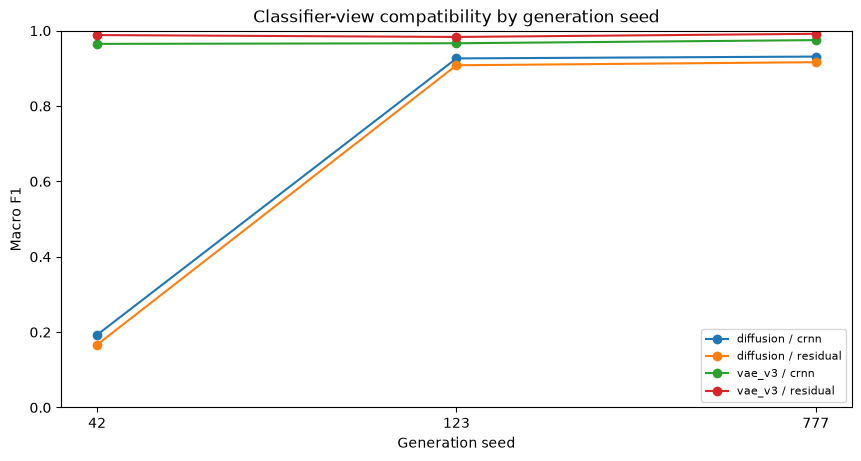

In [4]:
score_view = classifier_scores.sort_values(["model", "classifier", "seed"])[
    ["model", "classifier", "seed", "sample_count", "accuracy", "macro_f1", "macro_recall", "mean_confidence", "mean_entropy"]
]
display(score_view.style.format({
    "accuracy": "{:.2%}",
    "macro_f1": "{:.2%}",
    "macro_recall": "{:.2%}",
    "mean_confidence": "{:.3f}",
    "mean_entropy": "{:.3f}",
}))

score_aggregate = (
    classifier_scores
    .groupby(["model", "classifier"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_sample_sd=("accuracy", "std"),
        accuracy_min=("accuracy", "min"),
        accuracy_max=("accuracy", "max"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_sample_sd=("macro_f1", "std"),
        macro_f1_min=("macro_f1", "min"),
        macro_f1_max=("macro_f1", "max"),
    )
)
display(score_aggregate.style.format({
    column: "{:.2%}"
    for column in score_aggregate.columns
    if column not in {"model", "classifier"}
}))

fig, axis = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
for (model, classifier), frame in classifier_scores.groupby(["model", "classifier"]):
    axis.plot(frame["seed"].astype(str), frame["macro_f1"], marker="o", label=f"{model} / {classifier}")
axis.set(xlabel="Generation seed", ylabel="Macro F1", ylim=(0, 1), title="Classifier-view compatibility by generation seed")
axis.legend(loc="lower right", fontsize=8)
plt.show()


### Feature fidelity, manifold coverage, diversity, and copy risk


In [5]:
primary_metrics = metrics_aggregate[metrics_aggregate["classifier"] == "crnn"].copy()
primary_metric_columns = [
    "model", "species", "target_label_accuracy_mean", "species_recall_mean", "species_f1_mean",
    "frechet_mean_mean", "precision_mean_mean", "recall_mean_mean", "density_mean_mean",
    "coverage_mean_mean", "diversity_ratio_mean_mean", "diversity_delta_mean_mean",
    "pixel_distribution_wasserstein_mean",
]
display(primary_metrics[primary_metric_columns].sort_values(["model", "species"]).style.format({
    "target_label_accuracy_mean": "{:.2%}",
    "species_recall_mean": "{:.2%}",
    "species_f1_mean": "{:.2%}",
    "frechet_mean_mean": "{:.2f}",
    "precision_mean_mean": "{:.2%}",
    "recall_mean_mean": "{:.2%}",
    "density_mean_mean": "{:.2f}",
    "coverage_mean_mean": "{:.2%}",
    "diversity_ratio_mean_mean": "{:.2f}",
    "diversity_delta_mean_mean": "{:+.2f}",
    "pixel_distribution_wasserstein_mean": "{:.3f}",
}))

copy_risk_view = (
    nearest_neighbor_summary[nearest_neighbor_summary["classifier"] == "crnn"]
    .groupby(["model", "species"], as_index=False)
    .agg(
        generated_count=("generated_count", "max"),
        exact_train_duplicates=("exact_train_duplicate_count", "max"),
        validation_threshold=("copy_risk_threshold", "mean"),
        nearest_train_distance_median=("nearest_train_median", "mean"),
        below_threshold_fraction=("below_threshold_fraction", "mean"),
    )
)
display(copy_risk_view.sort_values(["model", "species"]).style.format({
    "validation_threshold": "{:.3f}",
    "nearest_train_distance_median": "{:.3f}",
    "below_threshold_fraction": "{:.2%}",
}))

signal_columns = [
    "model", "species", "real_time_gradient_energy_mean", "generated_time_gradient_energy_mean",
    "real_frequency_gradient_energy_mean", "generated_frequency_gradient_energy_mean",
    "real_dynamic_range_mean", "generated_dynamic_range_mean",
    "real_active_bin_fraction_mean", "generated_active_bin_fraction_mean",
    "pixel_distribution_wasserstein_mean",
]
display(primary_metrics[signal_columns].sort_values(["model", "species"]).style.format({column: "{:.3f}" for column in signal_columns[2:]}))


,model,species,target_label_accuracy_mean,species_recall_mean,species_f1_mean,frechet_mean_mean,precision_mean_mean,recall_mean_mean,density_mean_mean,coverage_mean_mean,diversity_ratio_mean_mean,diversity_delta_mean_mean,pixel_distribution_wasserstein_mean
0,diffusion,American Robin,62.67%,62.67%,62.43%,286.10,36.61%,53.70%,0.18,33.64%,0.95,-0.46,0.199
1,diffusion,Northern Cardinal,90.17%,90.17%,78.40%,132.05,56.51%,58.43%,0.35,42.53%,0.77,-3.42,0.146
2,diffusion,Song Sparrow,67.50%,67.50%,64.21%,212.04,25.47%,52.49%,0.10,21.69%,0.86,-1.54,0.284
6,vae_v3,American Robin,99.50%,99.50%,97.31%,14.00,76.19%,87.28%,0.48,67.62%,0.87,-1.32,0.091
7,vae_v3,Northern Cardinal,96.33%,96.33%,97.22%,41.22,90.52%,91.25%,0.69,73.83%,0.80,-2.91,0.087
8,vae_v3,Song Sparrow,94.83%,94.83%,96.12%,12.52,90.21%,91.84%,0.75,85.37%,0.93,-0.82,0.050


,model,species,generated_count,exact_train_duplicates,validation_threshold,nearest_train_distance_median,below_threshold_fraction
0,diffusion,American Robin,200,0,2.064,10.378,0.00%
1,diffusion,Northern Cardinal,200,0,2.666,5.455,4.17%
2,diffusion,Song Sparrow,200,0,2.482,8.690,1.17%
3,vae_v3,American Robin,200,0,2.064,2.827,16.83%
4,vae_v3,Northern Cardinal,200,0,2.666,2.750,47.67%
5,vae_v3,Song Sparrow,200,0,2.482,2.606,44.83%


,model,species,real_time_gradient_energy_mean,generated_time_gradient_energy_mean,real_frequency_gradient_energy_mean,generated_frequency_gradient_energy_mean,real_dynamic_range_mean,generated_dynamic_range_mean,real_active_bin_fraction_mean,generated_active_bin_fraction_mean,pixel_distribution_wasserstein_mean
0,diffusion,American Robin,0.092,0.129,0.070,0.119,1.965,1.971,0.864,0.679,0.199
1,diffusion,Northern Cardinal,0.108,0.161,0.072,0.131,1.963,1.894,0.921,0.767,0.146
2,diffusion,Song Sparrow,0.103,0.156,0.075,0.142,1.874,1.970,0.962,0.640,0.284
6,vae_v3,American Robin,0.092,0.076,0.070,0.041,1.965,1.975,0.864,0.903,0.091
7,vae_v3,Northern Cardinal,0.108,0.088,0.072,0.043,1.963,1.936,0.921,0.955,0.087
8,vae_v3,Song Sparrow,0.103,0.078,0.075,0.041,1.874,1.940,0.962,0.897,0.050


### Encoder dependence, seed stability, and claim boundary


,seed,accuracy,macro_f1,mean_confidence,mean_entropy
3,42,34.50%,19.28%,0.843,0.450
4,123,92.67%,92.64%,0.929,0.234
5,777,93.17%,93.13%,0.940,0.213


Diffusion seed-42 is a pronounced outlier: its CRNN macro F1 is 19.28%, versus the two later seeds. Keep this disagreement visible rather than pooling it away.
VAE-v3 is comparatively stable across seeds and both evaluators; residual and CRNN rankings are sensitivity evidence, not a composite winner.


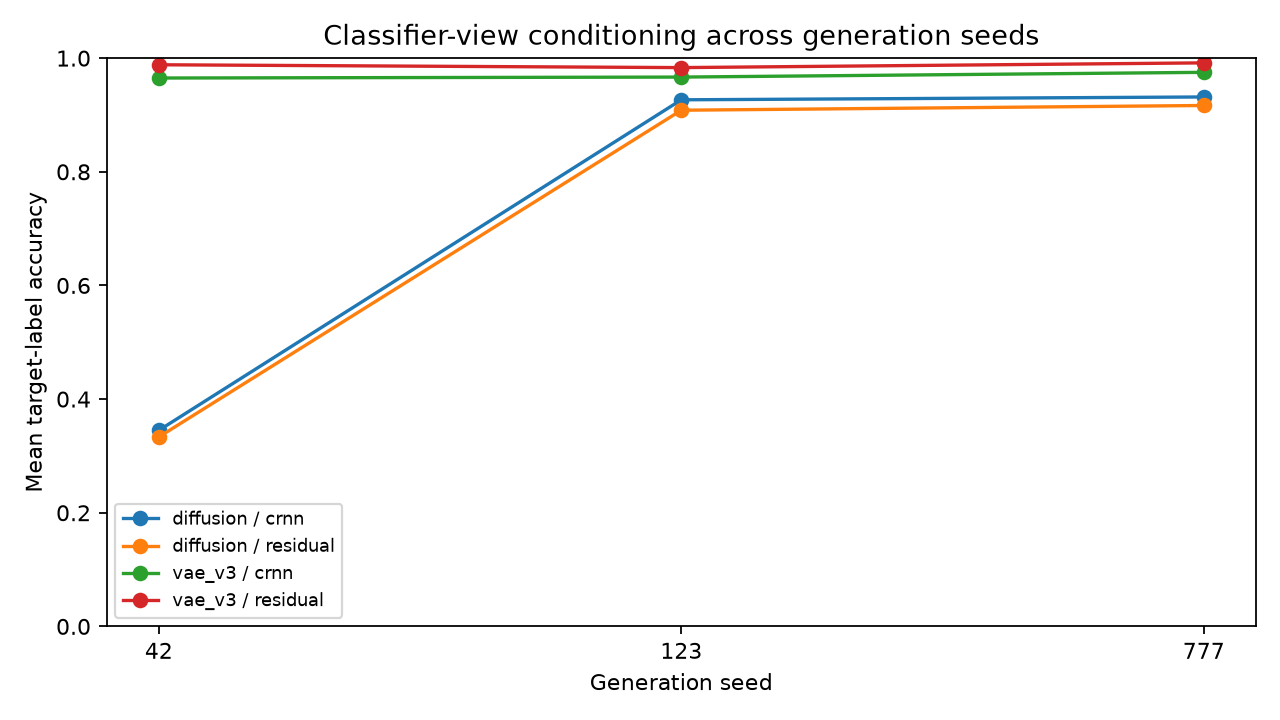

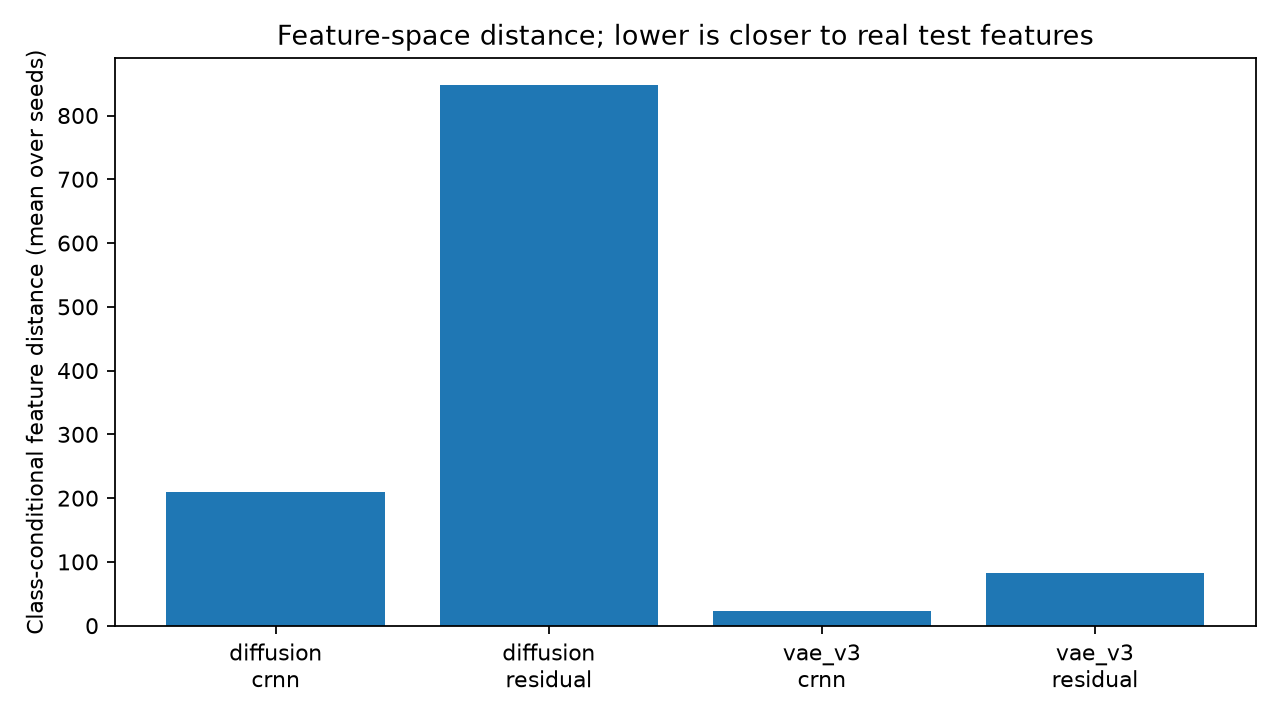

In [6]:
diffusion_seed_view = classifier_scores[
    (classifier_scores["model"] == "diffusion") & (classifier_scores["classifier"] == "crnn")
][["seed", "accuracy", "macro_f1", "mean_confidence", "mean_entropy"]].sort_values("seed")
display(diffusion_seed_view.style.format({
    "accuracy": "{:.2%}",
    "macro_f1": "{:.2%}",
    "mean_confidence": "{:.3f}",
    "mean_entropy": "{:.3f}",
}))

print(
    "Diffusion seed-42 is a pronounced outlier: its CRNN macro F1 is "
    f"{float(diffusion_seed_view.loc[diffusion_seed_view['seed'] == 42, 'macro_f1'].iloc[0]):.2%}, "
    "versus the two later seeds. Keep this disagreement visible rather than pooling it away."
)
print(
    "VAE-v3 is comparatively stable across seeds and both evaluators; residual and CRNN rankings "
    "are sensitivity evidence, not a composite winner."
)

for figure_name in ("conditioning_by_seed.png", "feature_distance_summary.png"):
    figure_path = CHECKPOINT_REPORT_ROOT / "figures" / figure_name
    if figure_path.is_file():
        display(Image(filename=str(figure_path), width=720))


### Part 1 conclusion and limitations

- **VAE-v3:** high target-label compatibility on all three seeds for both the
  selected CRNN and residual sensitivity encoder, with no exact train duplicates
  in the packaged pools.
- **Diffusion:** seeds 123 and 777 are strongly compatible, while seed 42 is a
  severe outlier for both evaluators. This is generation-seed instability, not a
  result that should be hidden by pooled statistics.
- **Distribution and diversity:** the report includes class-conditional feature
  distances, k=5 precision/recall/density/coverage, diversity relative to real
  clips, spectral summary differences, and validation-derived nearest-neighbor
  copy-risk thresholds. These support compatibility and distributional statements
  only.
- **Encoder dependence:** CRNN results are primary; residual results are a
  sensitivity check. If they disagree, the conclusion is encoder-dependent rather
  than a universal model ranking.

The supported claim boundary is classifier compatibility, conditioning,
classifier-feature similarity, diversity, coverage, copying risk, and
generation-seed stability. Part 1 does **not** establish waveform quality,
human-perceived realism, native generator test loss, training stability, or causal
augmentation improvement. Parts 2 and 3 remain separate because generator diagnostics alone do not
establish classifier utility.


## Part 2 — Full-data augmentation

### Result in brief

This part evaluates the recorded generated-plus-real CRNN augmentation
study. Validation selected 200 generated spectrograms per species for both
VAE-v3 and diffusion. On the selected ratios, VAE-v3 reached 89.48% mean test
macro F1 and diffusion reached 89.28%, below the historical selected CRNN
reference of 90.16%.

These are descriptive results, not a causal estimate: the baseline is one
historical seed trained through a different input pipeline and there is no
matched cached-real-only control.


### Context and methods

The study mixes fixed generated spectrogram rows into the full real training
set; it does not implement the MixUp interpolation algorithm. The tracked
report contains 18 validation runs: two generators, ratios 50/100/200 per
species, and seeds 42/123/777. Only the validation-selected ratio for each
generator was evaluated on the 489-clip test manifest.

### Key Assumptions

- The tracked report package is the portable source of truth.
- Historical provenance paths shown inside the report are not operational
  paths for this reorganized checkout.
- The recorded selection rule is preserved; this notebook does not reselect
  ratios using newer code or test results.


### Data and report audit


In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORT_ROOT = PROJECT_ROOT / "reports" / "crnn_synthetic_augmentation_2026-08-09"
LOCAL_RUN_ROOT = PROJECT_ROOT / "runs" / "crnn_synthetic_augmentation" / "cache_sweep"
INCLUDE_LOCAL_RUN_DETAILS = False

summary_payload = json.loads((REPORT_ROOT / "summary.json").read_text(encoding="utf-8"))
protocol_payload = json.loads((REPORT_ROOT / "protocol.json").read_text(encoding="utf-8"))
validation_summary = pd.read_csv(REPORT_ROOT / "validation_summary.csv")
test_summary = pd.read_csv(REPORT_ROOT / "test_summary.csv")

required_validation_columns = {
    "generator", "ratio_per_species", "seed", "best_validation_macro_f1",
    "mean_macro_f1_across_seeds", "selected_for_test",
}
required_test_columns = {
    "scope", "condition", "generator", "ratio_per_species", "seed",
    "accuracy", "macro_f1", "delta_accuracy_vs_historical",
    "delta_macro_f1_vs_historical",
}
assert required_validation_columns.issubset(validation_summary.columns)
assert required_test_columns.issubset(test_summary.columns)
assert len(validation_summary) == 18
assert validation_summary["seed"].nunique() == 3
assert set(validation_summary["generator"]) == {"vae_v3", "diffusion"}
assert set(validation_summary["ratio_per_species"]) == {50, 100, 200}
assert set(test_summary["scope"]) == {"historical_reference", "seed", "three_seed_mean"}
for generator in ("vae_v3", "diffusion"):
    recorded_mean = summary_payload["test_results"][generator]["mean_macro_f1"]
    table_mean = float(test_summary[
        (test_summary["scope"] == "three_seed_mean") & (test_summary["generator"] == generator)
    ].iloc[0]["macro_f1"])
    assert np.isclose(recorded_mean, table_mean, atol=1e-12)

print("Report:", REPORT_ROOT)
print("Question:", protocol_payload["task"])
print("Validation rows:", len(validation_summary))
print("Test rows:", len(test_summary))


Report: C:\Users\Harvey\Documents\Coding\bird_song_gen\reports\crnn_synthetic_augmentation_2026-08-09
Question: Evaluate whether adding fixed VAE-v3 or diffusion spectrogram pools improves a three-species CRNN.
Validation rows: 18
Test rows: 9


In [8]:
condition_rows = []
real_rows = protocol_payload["data_splits"]["train"]["clips"]
for ratio in protocol_payload["augmentation_conditions"]["ratios_per_species"]:
    generated_rows = ratio * 3
    condition_rows.append({
        "ratio_per_species": ratio,
        "real_rows": real_rows,
        "generated_rows": generated_rows,
        "train_rows": real_rows + generated_rows,
        "synthetic_row_share": generated_rows / (real_rows + generated_rows),
    })
condition_table = pd.DataFrame(condition_rows)
display(condition_table.style.format({"synthetic_row_share": "{:.2%}"}))


,ratio_per_species,real_rows,generated_rows,train_rows,synthetic_row_share
0,50,2339,150,2489,6.03%
1,100,2339,300,2639,11.37%
2,200,2339,600,2939,20.42%


### Results


#### Validation ratio selection


,generator,ratio_per_species,mean,sample_sd,runs,recorded_mean
0,diffusion,50,87.25%,1.59%,3,87.25%
1,diffusion,100,89.00%,0.69%,3,89.00%
2,diffusion,200,89.32%,1.88%,3,89.32%
3,vae_v3,50,88.73%,1.50%,3,88.73%
4,vae_v3,100,88.15%,1.41%,3,88.15%
5,vae_v3,200,89.23%,1.62%,3,89.23%


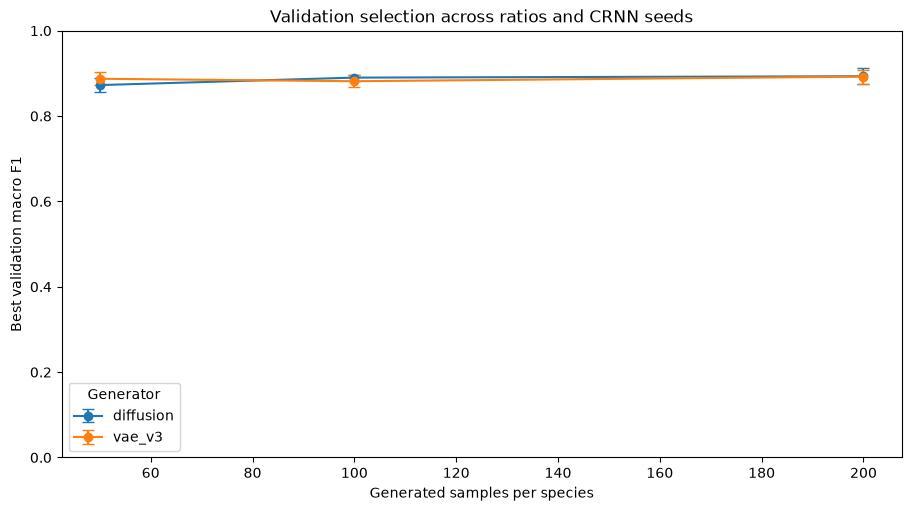

In [9]:
validation_grouped = (
    validation_summary
    .groupby(["generator", "ratio_per_species"])["best_validation_macro_f1"]
    .agg(mean="mean", sample_sd="std", runs="count")
    .reset_index()
)
recorded_means = (
    validation_summary
    .groupby(["generator", "ratio_per_species"])["mean_macro_f1_across_seeds"]
    .first()
    .reset_index(name="recorded_mean")
)
validation_grouped = validation_grouped.merge(recorded_means, on=["generator", "ratio_per_species"])
assert np.allclose(validation_grouped["mean"], validation_grouped["recorded_mean"], atol=1e-12)
display(validation_grouped.style.format({
    "mean": "{:.2%}",
    "sample_sd": "{:.2%}",
    "recorded_mean": "{:.2%}",
}))

fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
for generator, frame in validation_grouped.groupby("generator"):
    axis.errorbar(
        frame["ratio_per_species"],
        frame["mean"],
        yerr=frame["sample_sd"],
        marker="o",
        capsize=4,
        label=generator,
    )
axis.set(
    xlabel="Generated samples per species",
    ylabel="Best validation macro F1",
    ylim=(0, 1),
    title="Validation selection across ratios and CRNN seeds",
)
axis.legend(title="Generator")
plt.show()


#### Selected-ratio held-out results


In [10]:
selected_rows = validation_summary[validation_summary["selected_for_test"].astype(str).str.lower() == "true"]
selected_counts = selected_rows.groupby("generator")["ratio_per_species"].nunique()
assert selected_counts.to_dict() == {"vae_v3": 1, "diffusion": 1}
assert set(selected_rows["ratio_per_species"]) == {200}
selection_table = (
    selected_rows
    .groupby(["generator", "ratio_per_species"])["best_validation_macro_f1"]
    .agg(mean="mean", sample_sd="std")
    .reset_index()
)
display(selection_table.style.format({"mean": "{:.2%}", "sample_sd": "{:.2%}"}))
print("Recorded selected ratio: 200 generated samples per species for both generators.")


,generator,ratio_per_species,mean,sample_sd
0,diffusion,200,89.32%,1.88%
1,vae_v3,200,89.23%,1.62%


Recorded selected ratio: 200 generated samples per species for both generators.


,generator,ratio_per_species,mean,sample_sd,runs
0,diffusion,200,89.28%,1.51%,3
1,vae_v3,200,89.48%,2.76%,3


,condition,generator,ratio_per_species,accuracy,macro_f1,delta_accuracy_vs_historical,delta_macro_f1_vs_historical
4,vae_v3_augmented,vae_v3,200,89.43%,89.48%,-0.55%,-0.68%
8,diffusion_augmented,diffusion,200,89.23%,89.28%,-0.75%,-0.88%


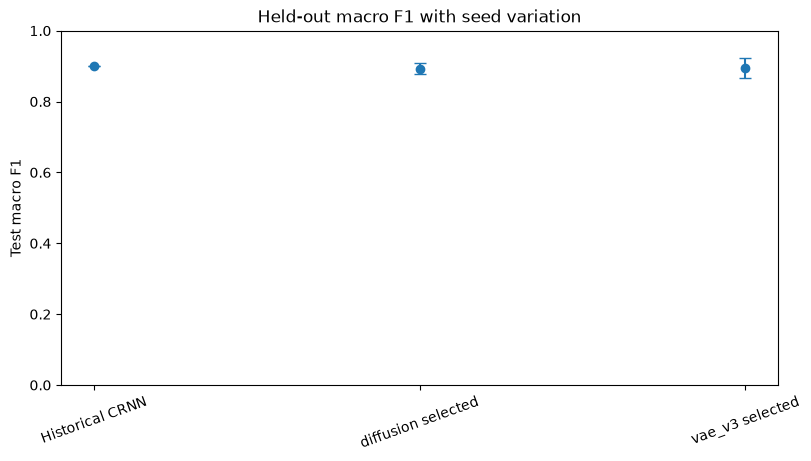

In [11]:
test_seed_rows = test_summary[test_summary["scope"] == "seed"].copy()
test_mean_rows = test_summary[test_summary["scope"] == "three_seed_mean"].copy()
historical_row = test_summary[test_summary["scope"] == "historical_reference"].iloc[0]
test_grouped = (
    test_seed_rows
    .groupby(["generator", "ratio_per_species"])["macro_f1"]
    .agg(mean="mean", sample_sd="std", runs="count")
    .reset_index()
)
display(test_grouped.style.format({"mean": "{:.2%}", "sample_sd": "{:.2%}"}))
display(test_mean_rows[[
    "condition", "generator", "ratio_per_species", "accuracy", "macro_f1",
    "delta_accuracy_vs_historical", "delta_macro_f1_vs_historical",
]].style.format({
    "accuracy": "{:.2%}",
    "macro_f1": "{:.2%}",
    "delta_accuracy_vs_historical": "{:+.2%}",
    "delta_macro_f1_vs_historical": "{:+.2%}",
}))

plot_rows = pd.concat([
    pd.DataFrame([{
        "condition": "Historical CRNN",
        "generator": "historical",
        "macro_f1": historical_row["macro_f1"],
        "sample_sd": 0.0,
    }]),
    test_grouped.rename(columns={"mean": "macro_f1"})[["generator", "macro_f1", "sample_sd"]]
    .assign(condition=lambda frame: frame["generator"] + " selected"),
], ignore_index=True)
fig, axis = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
positions = np.arange(len(plot_rows))
axis.errorbar(
    positions,
    plot_rows["macro_f1"],
    yerr=plot_rows["sample_sd"],
    fmt="o",
    capsize=4,
)
axis.set(
    xticks=positions,
    xticklabels=plot_rows["condition"],
    ylabel="Test macro F1",
    ylim=(0, 1),
    title="Held-out macro F1 with seed variation",
)
axis.tick_params(axis="x", rotation=20)
plt.show()


#### Species recall


In [12]:
recall_columns = [
    "recall_american_robin",
    "recall_northern_cardinal",
    "recall_song_sparrow",
]
recall_rows = [{
    "condition": "Historical CRNN",
    **{column: float(historical_row[column]) for column in recall_columns},
}]
for generator, frame in test_seed_rows.groupby("generator"):
    recall_rows.append({
        "condition": f"{generator} selected mean",
        **{column: float(frame[column].mean()) for column in recall_columns},
    })
recall_table = pd.DataFrame(recall_rows)
display(recall_table.style.format({column: "{:.2%}" for column in recall_columns}))


,condition,recall_american_robin,recall_northern_cardinal,recall_song_sparrow
0,Historical CRNN,95.17%,85.80%,89.56%
1,diffusion selected mean,94.71%,78.60%,94.32%
2,vae_v3 selected mean,93.10%,88.68%,87.18%


#### Optional local run details


In [13]:
if not INCLUDE_LOCAL_RUN_DETAILS:
    print("Local learning-curve details are disabled; tracked report tables remain the primary analysis.")
else:
    history_paths = sorted(LOCAL_RUN_ROOT.glob("*/*/seed_*/history.json"))
    if not history_paths:
        print("No ignored local histories found at:", LOCAL_RUN_ROOT)
    else:
        scalar_rows = []
        for history_path in history_paths:
            relative_parts = history_path.relative_to(LOCAL_RUN_ROOT).parts
            generator, ratio_name, seed_name = relative_parts[:3]
            history_payload = json.loads(history_path.read_text(encoding="utf-8"))
            for entry in history_payload:
                validation = entry.get("validation", {})
                scalar_rows.append({
                    "generator": generator,
                    "ratio_per_species": int(ratio_name.replace("ratio_", "")),
                    "seed": int(seed_name.replace("seed_", "")),
                    "step": entry["step"],
                    "validation_macro_f1": validation.get("macro_f1"),
                    "validation_accuracy": validation.get("accuracy"),
                })
        local_history = pd.DataFrame(scalar_rows)
        display(local_history.head())
        print("Loaded local history files:", len(history_paths))


Local learning-curve details are disabled; tracked report tables remain the primary analysis.


### Part 2 conclusion and limitations

Both generators selected 200 generated samples per species. VAE-v3 achieved
89.48% mean test macro F1 and diffusion achieved 89.28%, compared with 90.16%
for the historical selected CRNN. The supported statement is that neither
selected arm demonstrated a mean held-out gain in this first evaluation.

This does not establish that generated data harms performance. The reference is
one seed trained through the earlier WAV pipeline, the augmented arms use
three seeds and fixed cached real spectrograms, no matched cached-real-only
control was recorded, and only one generated-pool seed was tested. The
historical validation split also contains nine exact train duplicates, though
none reaches test.


## Part 3 — Low-resource augmentation

**Question.** If a newly initialized CRNN can see only 50 labeled real
spectrograms per species, do existing VAE-v3 or diffusion spectrograms improve
classification of real held-out clips?

This is a **report-only** companion to the completed matched experiment. It
loads bounded evidence from `reports/crnn_low_resource_augmentation_2026-08-10/`
and never reads checkpoints, trains a model, or generates a spectrogram.

The experiment simulates classifier-label scarcity for the repository's three
common species. It is not evidence about genuinely rare or unseen species.


In [14]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the bird_song_gen project root")


PROJECT_ROOT = find_project_root(Path.cwd())
REPORT_DIR = PROJECT_ROOT / "reports/crnn_low_resource_augmentation_2026-08-10"
required = [
    "protocol.json",
    "summary.json",
    "validation_selection.csv",
    "test_aggregate.csv",
    "test_per_run.csv",
    "paired_deltas.csv",
    "paired_summary.csv",
    "subset_membership.csv",
    "subset_overlap.csv",
]
missing = [name for name in required if not (REPORT_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete report package; missing: {missing}")

protocol = json.loads((REPORT_DIR / "protocol.json").read_text(encoding="utf-8"))
summary = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
validation = pd.read_csv(REPORT_DIR / "validation_selection.csv")
test_aggregate = pd.read_csv(REPORT_DIR / "test_aggregate.csv")
test_per_run = pd.read_csv(REPORT_DIR / "test_per_run.csv")
paired = pd.read_csv(REPORT_DIR / "paired_deltas.csv")
paired_summary = pd.read_csv(REPORT_DIR / "paired_summary.csv")
membership = pd.read_csv(REPORT_DIR / "subset_membership.csv")
subset_overlap = pd.read_csv(REPORT_DIR / "subset_overlap.csv")

COLORS = {"Real only": "#5B6770", "VAE-v3 +200": "#2E86AB", "Diffusion +200": "#E07A5F"}
CONDITION_LABELS = {
    "real_only": "Real only",
    "vae_v3_plus_200": "VAE-v3 +200",
    "diffusion_plus_200": "Diffusion +200",
}
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
print(f"Report package loaded: {REPORT_DIR.relative_to(PROJECT_ROOT)}")

Report package loaded: reports\crnn_low_resource_augmentation_2026-08-10


### Report and schema audit

The notebook first verifies the portable package. This catches an incomplete or
incompatible report before any chart is interpreted.


In [15]:
assert protocol["schema_version"] == 1
assert summary["schema_version"] == 1
assert protocol["real_per_species"] == 50
assert protocol["ratios_per_species"] == [50, 100, 200]
assert len(protocol["replicate_blocks"]) == 9
assert set(summary["selected_ratios"]) == {"vae_v3", "diffusion"}
assert summary["selected_ratios"] == {"vae_v3": 200, "diffusion": 200}

expected_validation = {
    (generator, ratio)
    for generator in ("vae_v3", "diffusion")
    for ratio in (50, 100, 200)
}
assert set(zip(validation["generator"], validation["ratio_per_species"])) == expected_validation
assert validation["runs"].eq(9).all()
assert validation["selected_for_test"].sum() == 2
assert set(test_aggregate["condition"]) == set(CONDITION_LABELS)
assert test_aggregate["runs"].eq(9).all()
assert len(test_per_run) == 27
assert test_per_run["sample_count"].eq(489).all()
assert len(paired) == 18 and paired_summary["paired_blocks"].eq(9).all()

membership_counts = membership.groupby(
    ["low_resource_subset_seed", "name"]
).size()
recording_counts = membership.groupby(
    ["low_resource_subset_seed", "name"]
)["id"].nunique()
assert membership_counts.eq(50).all()
assert recording_counts.eq(50).all()
assert len(membership) == 450
assert len(subset_overlap) == 9

audit = pd.DataFrame(
    {
        "Check": [
            "Matched blocks",
            "Training runs represented in validation",
            "Held-out evaluations",
            "Test clips per evaluation",
            "Real subset rows",
            "Distinct recording IDs per subset/species",
        ],
        "Observed": [9, int(validation["runs"].sum() + 9), 27, 489, 450, 50],
        "Status": ["pass"] * 6,
    }
)
display(audit)
print("Report schema and experiment counts passed.")

,Check,Observed,Status
0,Matched blocks,9,pass
1,Training runs represented in validation,63,pass
2,Held-out evaluations,27,pass
3,Test clips per evaluation,489,pass
4,Real subset rows,450,pass
5,Distinct recording IDs per subset/species,50,pass


Report schema and experiment counts passed.


### Experimental design

- Each real subset contains 50 rows per species, each from a different recording
  ID in `content_safe_v2` training data.
- Three real-subset seeds × three CRNN initialization seeds form nine matched
  blocks. Generation-pool seeds 42, 123, and 777 rotate by Latin square.
- Every block trains a real-only control and VAE-v3/diffusion arms with +50,
  +100, or +200 generated rows per species: 7 conditions × 9 blocks = 63 runs.
- All conditions use the same from-scratch CRNN, 1,440 optimizer steps,
  real-only validation set, and the same post-cache masking policy for real and
  generated training rows.
- Validation chooses one ratio per generator. Test is then used only for the
  real-only controls and the two selected arms.


In [16]:
design = pd.DataFrame(
    {
        "Design element": [
            "Real rows per species",
            "Generated rows per species tested",
            "Real-subset seeds",
            "CRNN training seeds",
            "Generation-pool seeds",
            "Matched blocks",
            "Total CRNN training runs",
            "Held-out test clips",
        ],
        "Value": [
            protocol["real_per_species"],
            ", ".join(map(str, protocol["ratios_per_species"])),
            ", ".join(map(str, protocol["real_subset_seeds"])),
            ", ".join(map(str, protocol["train_seeds"])),
            ", ".join(map(str, protocol["pool_seeds"])),
            len(protocol["replicate_blocks"]),
            63,
            int(test_per_run["sample_count"].iloc[0]),
        ],
    }
)
display(design)

shares = pd.DataFrame(
    {
        "Generated per species": protocol["ratios_per_species"],
        "Real per species": protocol["real_per_species"],
    }
)
shares["Total training rows per species"] = (
    shares["Generated per species"] + shares["Real per species"]
)
shares["Synthetic share"] = (
    shares["Generated per species"] / shares["Total training rows per species"]
)
display(shares.style.format({"Synthetic share": "{:.1%}"}))

,Design element,Value
0,Real rows per species,50
1,Generated rows per species tested,"50, 100, 200"
2,Real-subset seeds,"101, 202, 303"
3,CRNN training seeds,"42, 123, 777"
4,Generation-pool seeds,"42, 123, 777"
5,Matched blocks,9
6,Total CRNN training runs,63
7,Held-out test clips,489


,Generated per species,Real per species,Total training rows per species,Synthetic share
0,50,50,100,50.0%
1,100,50,150,66.7%
2,200,50,250,80.0%


#### Real-subset dependence

The subsets use distinct recording IDs *within* a subset, but the three subsets
cannot be disjoint. The source split has only 56 Robin, 63 Cardinal, and 95
Sparrow recording IDs. Therefore, the nine matched blocks support a descriptive
stability analysis, not nine independent external replications.


In [17]:
overlap_view = subset_overlap.rename(
    columns={
        "species": "Species",
        "subset_seed_a": "Subset A",
        "subset_seed_b": "Subset B",
        "shared_recording_ids": "Shared recording IDs",
        "union_recording_ids": "Union recording IDs",
        "jaccard_overlap": "Jaccard overlap",
    }
)
display(overlap_view.style.format({"Jaccard overlap": "{:.1%}"}))

,Species,Subset A,Subset B,Shared recording IDs,Union recording IDs,Jaccard overlap
0,American Robin,101,202,45,55,81.8%
1,American Robin,101,303,44,56,78.6%
2,American Robin,202,303,46,54,85.2%
3,Northern Cardinal,101,202,39,61,63.9%
4,Northern Cardinal,101,303,38,62,61.3%
5,Northern Cardinal,202,303,41,59,69.5%
6,Song Sparrow,101,202,29,71,40.8%
7,Song Sparrow,101,303,27,73,37.0%
8,Song Sparrow,202,303,28,72,38.9%


### Validation-only ratio selection

Both generators selected +200 per species from the mean best validation macro
F1 across nine blocks. The selection rule chooses the smallest ratio within
0.002 of the best mean. Because +200 is the largest existing pool size, it is
the **best tested ratio**, not evidence that performance has saturated or that
200 is the true optimum.


,Generator,Generated/species,Runs,Mean macro F1,Sample SD,Minimum,Maximum,Selected
0,VAE-v3,50,9,84.33%,2.01%,81.65%,87.27%,False
1,VAE-v3,100,9,86.18%,1.70%,83.58%,89.26%,False
2,VAE-v3,200,9,86.67%,2.13%,83.12%,90.04%,True
3,Diffusion,50,9,83.80%,2.65%,79.49%,88.57%,False
4,Diffusion,100,9,84.71%,3.08%,78.53%,89.10%,False
5,Diffusion,200,9,85.09%,3.35%,77.83%,88.42%,True


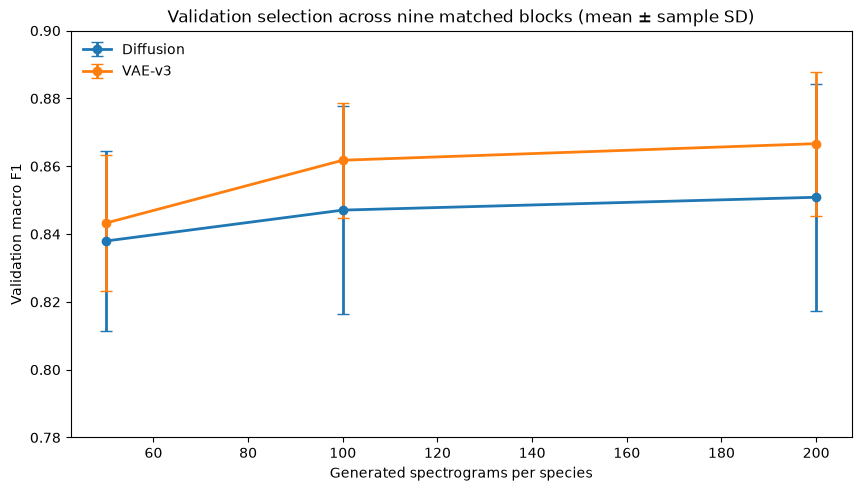

In [18]:
validation_view = validation[
    [
        "generator",
        "ratio_per_species",
        "runs",
        "validation_macro_f1_mean",
        "validation_macro_f1_sample_sd",
        "validation_macro_f1_min",
        "validation_macro_f1_max",
        "selected_for_test",
    ]
].copy()
validation_view["generator"] = validation_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
validation_view = validation_view.rename(
    columns={
        "generator": "Generator",
        "ratio_per_species": "Generated/species",
        "runs": "Runs",
        "validation_macro_f1_mean": "Mean macro F1",
        "validation_macro_f1_sample_sd": "Sample SD",
        "validation_macro_f1_min": "Minimum",
        "validation_macro_f1_max": "Maximum",
        "selected_for_test": "Selected",
    }
)
display(
    validation_view.style.format(
        {
            "Mean macro F1": "{:.2%}",
            "Sample SD": "{:.2%}",
            "Minimum": "{:.2%}",
            "Maximum": "{:.2%}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
for generator, group in validation_view.groupby("Generator"):
    ordered = group.sort_values("Generated/species")
    ax.errorbar(
        ordered["Generated/species"],
        ordered["Mean macro F1"],
        yerr=ordered["Sample SD"],
        marker="o",
        capsize=4,
        linewidth=2,
        label=generator,
    )
ax.set(
    xlabel="Generated spectrograms per species",
    ylabel="Validation macro F1",
    ylim=(0.78, 0.90),
    title="Validation selection across nine matched blocks (mean ± sample SD)",
)
ax.legend(frameon=False)
plt.show()

### Held-out classifier utility

The primary comparison is paired within each real-subset/training-seed block.
The interval below is a deterministic bootstrap over the nine matched blocks.
It is a descriptive stability summary—not a p-value, not a confidence interval
over test recordings, and not evidence from nine independent datasets.


In [19]:
aggregate_view = test_aggregate[
    [
        "condition",
        "runs",
        "accuracy_mean",
        "accuracy_sample_sd",
        "macro_f1_mean",
        "macro_f1_sample_sd",
        "macro_f1_min",
        "macro_f1_max",
        "minimum_species_recall_mean",
    ]
].copy()
aggregate_view["condition"] = aggregate_view["condition"].map(CONDITION_LABELS)
aggregate_view = aggregate_view.rename(
    columns={
        "condition": "Condition",
        "runs": "Runs",
        "accuracy_mean": "Mean accuracy",
        "accuracy_sample_sd": "Accuracy SD",
        "macro_f1_mean": "Mean macro F1",
        "macro_f1_sample_sd": "Macro-F1 SD",
        "macro_f1_min": "Macro-F1 minimum",
        "macro_f1_max": "Macro-F1 maximum",
        "minimum_species_recall_mean": "Mean worst-species recall",
    }
)
display(
    aggregate_view.style.format(
        {column: "{:.2%}" for column in aggregate_view.columns if column not in {"Condition", "Runs"}}
    )
)

paired_view = paired_summary[
    [
        "generator",
        "selected_ratio_per_species",
        "paired_blocks",
        "delta_macro_f1_mean",
        "delta_macro_f1_sample_sd",
        "delta_macro_f1_min",
        "delta_macro_f1_max",
        "delta_macro_f1_bootstrap_95_low",
        "delta_macro_f1_bootstrap_95_high",
        "delta_macro_f1_positive_blocks",
    ]
].copy()
paired_view["generator"] = paired_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
paired_view = paired_view.rename(
    columns={
        "generator": "Generator",
        "selected_ratio_per_species": "Selected generated/species",
        "paired_blocks": "Blocks",
        "delta_macro_f1_mean": "Mean paired delta",
        "delta_macro_f1_sample_sd": "Delta SD",
        "delta_macro_f1_min": "Minimum delta",
        "delta_macro_f1_max": "Maximum delta",
        "delta_macro_f1_bootstrap_95_low": "Interval low",
        "delta_macro_f1_bootstrap_95_high": "Interval high",
        "delta_macro_f1_positive_blocks": "Positive blocks",
    }
)
display(
    paired_view.style.format(
        {
            "Mean paired delta": "{:+.2%}",
            "Delta SD": "{:.2%}",
            "Minimum delta": "{:+.2%}",
            "Maximum delta": "{:+.2%}",
            "Interval low": "{:+.2%}",
            "Interval high": "{:+.2%}",
        }
    )
)

,Condition,Runs,Mean accuracy,Accuracy SD,Mean macro F1,Macro-F1 SD,Macro-F1 minimum,Macro-F1 maximum,Mean worst-species recall
0,Real only,9,84.78%,2.42%,84.75%,2.52%,81.02%,90.00%,75.38%
1,VAE-v3 +200,9,87.64%,1.35%,87.69%,1.37%,85.75%,90.24%,81.68%
2,Diffusion +200,9,85.23%,2.20%,85.17%,2.23%,81.41%,88.10%,77.78%


,Generator,Selected generated/species,Blocks,Mean paired delta,Delta SD,Minimum delta,Maximum delta,Interval low,Interval high,Positive blocks
0,Diffusion,200,9,+0.42%,2.53%,-4.41%,+3.00%,-1.19%,+1.85%,5
1,VAE-v3,200,9,+2.93%,2.55%,-0.22%,+7.56%,+1.43%,+4.54%,8


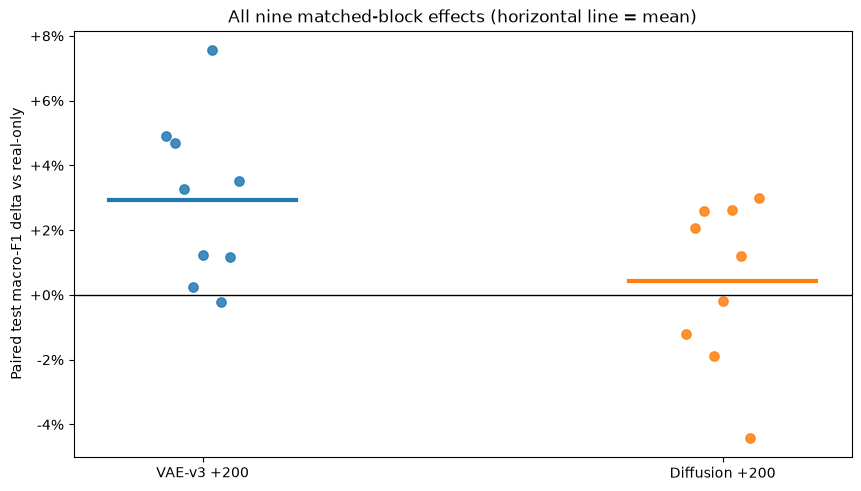

,Generator,Real-subset seed,CRNN seed,Pool seed,Paired macro-F1 delta
0,VAE-v3,101,42,42.000000,+4.90%
1,VAE-v3,101,123,123.000000,+4.70%
2,VAE-v3,101,777,777.000000,+3.27%
3,VAE-v3,202,42,123.000000,+0.24%
4,VAE-v3,202,123,777.000000,+1.24%
5,VAE-v3,202,777,42.000000,+7.56%
6,VAE-v3,303,42,777.000000,-0.22%
7,VAE-v3,303,123,42.000000,+1.18%
8,VAE-v3,303,777,123.000000,+3.53%
9,Diffusion,101,42,42.000000,-1.21%


In [20]:
plot_data = paired.copy()
plot_data["Generator"] = plot_data["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
positions = {"VAE-v3": 0, "Diffusion": 1}
ax.axhline(0, color="black", linewidth=1)
for generator, group in plot_data.groupby("Generator", sort=False):
    x = positions[generator]
    jitter = np.linspace(-0.07, 0.07, len(group))
    ax.scatter(
        np.full(len(group), x) + jitter,
        group["delta_macro_f1"],
        s=45,
        alpha=0.85,
        label=generator,
    )
    ax.plot([x - 0.18, x + 0.18], [group["delta_macro_f1"].mean()] * 2, linewidth=3)
ax.set(
    xticks=[0, 1],
    xticklabels=["VAE-v3 +200", "Diffusion +200"],
    ylabel="Paired test macro-F1 delta vs real-only",
    title="All nine matched-block effects (horizontal line = mean)",
)
ax.yaxis.set_major_formatter(lambda value, position: f"{value:+.0%}")
plt.show()

block_view = paired[
    ["generator", "real_subset_seed", "train_seed", "pool_seed", "delta_macro_f1"]
].copy()
block_view["generator"] = block_view["generator"].map(
    {"vae_v3": "VAE-v3", "diffusion": "Diffusion"}
)
block_view = block_view.rename(
    columns={
        "generator": "Generator",
        "real_subset_seed": "Real-subset seed",
        "train_seed": "CRNN seed",
        "pool_seed": "Pool seed",
        "delta_macro_f1": "Paired macro-F1 delta",
    }
)
display(block_view.style.format({"Paired macro-F1 delta": "{:+.2%}"}))

### Species recall

Macro F1 gives each species equal weight, but it can hide which class changes.
The table below compares mean recall across the same nine blocks.


,Condition,Species,Mean recall,Delta vs real-only
0,Real only,American Robin,90.57%,+0.00%
1,VAE-v3 +200,American Robin,94.18%,+3.60%
2,Diffusion +200,American Robin,91.11%,+0.54%
3,Real only,Northern Cardinal,75.38%,+0.00%
4,VAE-v3 +200,Northern Cardinal,81.96%,+6.58%
5,Diffusion +200,Northern Cardinal,77.78%,+2.40%
6,Real only,Song Sparrow,88.52%,+0.00%
7,VAE-v3 +200,Song Sparrow,87.48%,-1.04%
8,Diffusion +200,Song Sparrow,87.18%,-1.34%


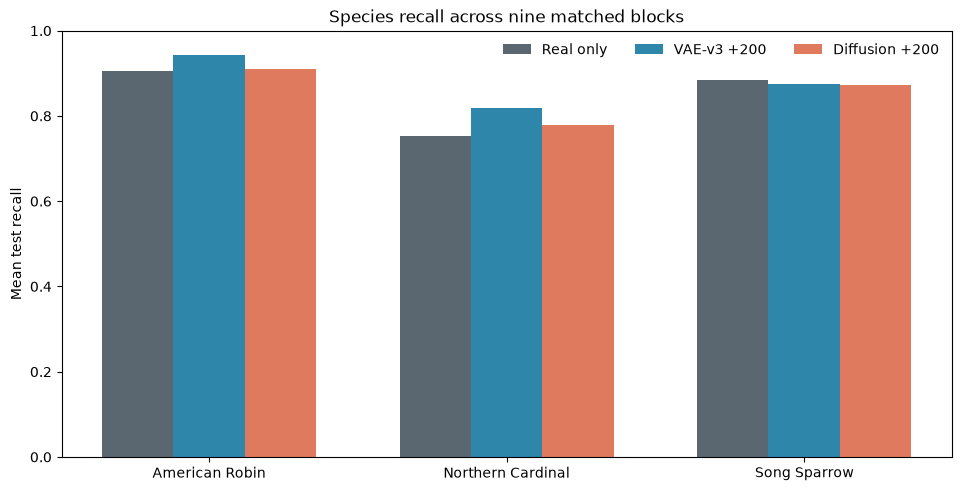

In [21]:
species_columns = {
    "recall_american_robin_mean": "American Robin",
    "recall_northern_cardinal_mean": "Northern Cardinal",
    "recall_song_sparrow_mean": "Song Sparrow",
}
species = test_aggregate[["condition", *species_columns]].copy()
species["condition"] = species["condition"].map(CONDITION_LABELS)
species = species.rename(columns={"condition": "Condition", **species_columns})
baseline = species.loc[species["Condition"] == "Real only"].iloc[0]

species_long = species.melt(
    id_vars="Condition", var_name="Species", value_name="Mean recall"
)
species_long["Delta vs real-only"] = species_long.apply(
    lambda row: row["Mean recall"] - baseline[row["Species"]], axis=1
)
display(
    species_long.style.format(
        {"Mean recall": "{:.2%}", "Delta vs real-only": "{:+.2%}"}
    )
)

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
species_names = list(species_columns.values())
x = np.arange(len(species_names))
width = 0.24
for index, (_, row) in enumerate(species.iterrows()):
    values = [row[name] for name in species_names]
    ax.bar(
        x + (index - 1) * width,
        values,
        width,
        label=row["Condition"],
        color=COLORS[row["Condition"]],
    )
ax.set(
    xticks=x,
    xticklabels=species_names,
    ylabel="Mean test recall",
    ylim=(0, 1.0),
    title="Species recall across nine matched blocks",
)
ax.legend(frameon=False, ncols=3)
plt.show()

### Part 3 conclusion and limitations

**Result within this protocol:**

- **VAE-v3 +200/species supports the classifier-utility claim.** Mean test macro
  F1 rose from 84.75% to 87.69%: a paired gain of **2.93 percentage points**.
  Eight of nine blocks improved, with a descriptive block-bootstrap interval of
  +1.43 to +4.54 points. Mean Cardinal recall increased by 6.58 points and Robin
  recall by 3.60 points; Sparrow recall decreased by 1.04 points.
- **Diffusion +200/species did not demonstrate a stable gain.** Mean test macro
  F1 was 85.17%, only +0.42 points over real-only. Five of nine blocks improved,
  and the descriptive interval (-1.19 to +1.85 points) spans both harm and gain.

**What this supports:** With access to the already-trained VAE-v3 and its
existing pools, synthetic spectrograms can help this CRNN under a simulated
50-labels-per-species constraint.

**What this does not support:**

- The three evaluated species are not rare or unseen.
- The pretrained generators saw more source data than the classifier-visible
  50 examples per species.
- The real subsets overlap and the nine blocks are not independent datasets.
- Generation-pool seed is rotated rather than fully crossed with every subset
  and CRNN seed, so all interactions cannot be separated.
- The 489-clip test set has prior project evaluation history and is not a new
  external holdout.
- +200 is the largest available ratio, so the study does not locate an optimum.
- Classifier utility does not establish spectrogram realism, waveform quality,
  or human-perceived quality.

For a stronger rare-species claim, repeat the same matched design on genuinely
rare species with a new external test set and a generator whose training-data
exposure is explicitly documented.


### Reproduction boundary

The full experiment is implemented by
`scripts/15_crnn_low_resource_augmentation.py`. From the repository root:

```powershell
$env:PYTHONPATH = (Resolve-Path "src").Path
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py audit
& ..\bird_song_venv\Scripts\python.exe `
  scripts/15_crnn_low_resource_augmentation.py run --device cuda --workers 0
```

The command reuses existing VAE-v3 and diffusion arrays. It trains only the
CRNN conditions, keeps checkpoints and histories under ignored `runs/`, and
promotes only bounded evidence to `reports/`.


## Part 4 — Cross-study conclusion

The three studies are complementary rather than interchangeable. Part 1 judges
the generated samples themselves through frozen classifiers and feature-space
diagnostics. Parts 2 and 3 judge downstream CRNN utility under different
amounts of real labeled data. Their baselines and matching designs differ, so
their deltas should not be pooled into one score.


In [22]:
part1_vae = conditioning_summary.loc["vae_v3"]
part1_diffusion = conditioning_summary.loc["diffusion"]

full_data_means = test_mean_rows.set_index("generator")
full_data_reference = float(historical_row["macro_f1"])

low_resource_aggregate = test_aggregate.set_index("condition")
low_resource_paired = paired_summary.set_index("generator")

cross_study_summary = pd.DataFrame(
    [
        {
            "Part": "1 — Generator quality",
            "Question": "Are generated samples compatible and stable?",
            "Headline evidence": (
                f"VAE-v3 CRNN F1 {part1_vae['mean']:.2%} ± {part1_vae['sample_sd']:.2%}; "
                f"diffusion {part1_diffusion['mean']:.2%} ± {part1_diffusion['sample_sd']:.2%}, "
                f"with seed range {part1_diffusion['minimum']:.2%}–{part1_diffusion['maximum']:.2%}."
            ),
            "Supported answer": "VAE-v3 is stable; diffusion is strongly generation-seed dependent.",
        },
        {
            "Part": "2 — Full-data augmentation",
            "Question": "Does synthetic data improve the full-data CRNN?",
            "Headline evidence": (
                f"Historical CRNN {full_data_reference:.2%}; VAE-v3 {float(full_data_means.loc['vae_v3', 'macro_f1']):.2%}; "
                f"diffusion {float(full_data_means.loc['diffusion', 'macro_f1']):.2%}."
            ),
            "Supported answer": "Neither arm demonstrated a mean held-out gain in this unmatched comparison.",
        },
        {
            "Part": "3 — Low-resource augmentation",
            "Question": "Can existing generated data help with 50 real labels/species?",
            "Headline evidence": (
                f"Real-only {float(low_resource_aggregate.loc['real_only', 'macro_f1_mean']):.2%}; "
                f"VAE-v3 +200 paired delta {float(low_resource_paired.loc['vae_v3', 'delta_macro_f1_mean']):+.2%}; "
                f"diffusion +200 {float(low_resource_paired.loc['diffusion', 'delta_macro_f1_mean']):+.2%}."
            ),
            "Supported answer": "VAE-v3 helped within this simulated label-scarcity design; diffusion did not show a stable gain.",
        },
    ]
)
display(cross_study_summary)


,Part,Question,Headline evidence,Supported answer
0,1 — Generator quality,Are generated samples compatible and stable?,VAE-v3 CRNN F1 96.88% ± 0.54%; diffusion 68.35...,VAE-v3 is stable; diffusion is strongly genera...
1,2 — Full-data augmentation,Does synthetic data improve the full-data CRNN?,Historical CRNN 90.16%; VAE-v3 89.48%; diffusi...,Neither arm demonstrated a mean held-out gain ...
2,3 — Low-resource augmentation,Can existing generated data help with 50 real ...,Real-only 84.75%; VAE-v3 +200 paired delta +2....,VAE-v3 helped within this simulated label-scar...


### Final answer

**The strongest supported conclusion is conditional:** generated
spectrograms can help this CRNN when labeled real examples are scarce, but the
benefit depends on the generator and data regime.

- VAE-v3 provides the clearest chain of evidence: stable classifier
  compatibility in Part 1 and a +2.93-point paired macro-F1 gain in Part 3,
  positive in eight of nine matched blocks.
- Diffusion cannot be summarized by its mean alone. Its seed-42 pool failed the
  classifier-compatibility check, and its low-resource gain was only +0.42
  points with a descriptive interval spanning harm and benefit.
- The full-data result does not contradict the low-resource result. When the
  CRNN already has the complete real training set, neither generated-data arm
  demonstrated additional mean held-out benefit; under 50 real labels per
  species, the VAE-v3 pool supplied useful classifier signal.
- Part 1 also prevents an overly simple “VAE wins” claim: the VAE copy-risk
  screen flagged substantially more near-training examples than diffusion,
  although neither pool contained an exact training duplicate and the flag is
  not proof of memorization.

**Presentation-safe claim:** “In a matched simulation with 50 labeled real
spectrograms per species, adding 200 existing VAE-v3 spectrograms per species
improved CRNN macro F1 by 2.93 percentage points on average. The same benefit
was not demonstrated for diffusion or in the historical full-data study.”

This does not yet establish performance for genuinely rare or unseen species,
human-perceived realism, waveform quality, a universally optimal synthetic
ratio, or causal improvement outside the tested protocol. The next strongest
test would use genuinely rare species, documented generator exposure, and a new
external holdout.
